#**스마트폰 센서 데이터 기반 모션 분류**
# 단계3 : 단계별 모델링


## 0.미션4

* 단계별로 나눠서 모델링을 수행하고자 합니다.  
* 단계 구분 예시
    * 단계1 : 정적(0), 동적(1) 행동 분류 모델 생성
    * 단계2 : 세부 동작에 대한 분류모델 생성
        * 단계1 모델에서 0으로 예측 -> 정적 행동 3가지 분류 모델링
        * 단계1 모델에서 1으로 예측 -> 동적 행동 3가지 분류 모델링
* 모델 통합
    * 두 단계 모델을 통합하고, 새로운 데이터에 대해서 최종 예측결과와 성능평가가 나오도록 함수로 만들기
* 성능 비교
    * 기본 모델링의 성능과 비교
    * 성능 가이드
        * Accuracy : 0.97 ~ 0.99
* 파이프라인 구성
    * test 데이터를 입력하여, 전처리 및 예측결과가 나오도록 함수 구성

## 1.환경설정

* 세부 요구사항
    - 경로 설정 : 구글콜랩
        * 구글 드라이브 바로 밑에 project3 폴더를 만들고,
        * 데이터 파일을 복사해 넣습니다.
    - 기본적으로 필요한 라이브러리를 import 하도록 코드가 작성되어 있습니다.
        * 필요하다고 판단되는 라이브러리를 추가하세요.


### (1) 경로 설정

* 구글 드라이브 연결

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
path = '/content/drive/MyDrive/Deep_learning/project3/'

### (2) 라이브러리 불러오기

* 라이브러리 로딩

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import *

from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout
from keras.backend import clear_session
from keras.optimizers import Adam

In [ ]:
# 학습곡선 함수
def dl_history_plot(history):
    plt.figure(figsize=(10,6))
    plt.plot(history['loss'], label='train_err', marker = '.')
    plt.plot(history['val_loss'], label='val_err', marker = '.')

    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

### (3) 데이터 불러오기

* 주어진 데이터셋
    * data01_train.csv : 학습 및 검증용
    * data01_test.csv : 테스트용
    * feature.csv : feature 이름을 계층구조로 정리한 데이터

* 세부 요구사항
    * 칼럼 삭제 : data01_train.csv와 data01_test.csv 에서 'subject' 칼럼은 불필요하므로 삭제합니다.

#### 1) 데이터로딩

In [ ]:
train_data = pd.read_csv(path + 'data01_train.csv')
test_data = pd.read_csv(path + 'data01_test.csv')

In [ ]:
train_data = train_data.drop(columns=['subject'])
test_data = test_data.drop(columns=['subject'])

#### 2) 기본 정보 조회

In [ ]:
train_data.head(3)

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",Activity
0,0.288508,-0.009196,-0.103362,-0.988986,-0.962797,-0.967422,-0.989000,-0.962596,-0.965650,-0.929747,...,-0.487737,-0.816696,-0.042494,-0.044218,0.307873,0.072790,-0.601120,0.331298,0.165163,STANDING
1,0.265757,-0.016576,-0.098163,-0.989551,-0.994636,-0.987435,-0.990189,-0.993870,-0.987558,-0.937337,...,-0.237820,-0.693515,-0.062899,0.388459,-0.765014,0.771524,0.345205,-0.769186,-0.147944,LAYING
2,0.278709,-0.014511,-0.108717,-0.997720,-0.981088,-0.994008,-0.997934,-0.982187,-0.995017,-0.942584,...,-0.535287,-0.829311,0.000265,-0.525022,-0.891875,0.021528,-0.833564,0.202434,-0.032755,STANDING


In [ ]:
train_data.shape

(5881, 562)

In [ ]:
train_data.describe()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
count,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,...,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000
mean,0.274811,-0.017799,-0.109396,-0.603138,-0.509815,-0.604058,-0.628151,-0.525944,-0.605374,-0.465490,...,0.126955,-0.305883,-0.623548,0.008524,-0.001185,0.009340,-0.007099,-0.491501,0.059299,-0.054594
std,0.067614,0.039422,0.058373,0.448807,0.501815,0.417319,0.424345,0.485115,0.413043,0.544995,...,0.249176,0.322808,0.310371,0.339730,0.447197,0.608190,0.476738,0.509069,0.297340,0.278479
min,-0.503823,-0.684893,-1.000000,-1.000000,-0.999844,-0.999667,-1.000000,-0.999419,-1.000000,-1.000000,...,-0.965725,-0.979261,-0.999765,-0.976580,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-0.980143
25%,0.262919,-0.024877,-0.121051,-0.992774,-0.977680,-0.980127,-0.993602,-0.977865,-0.980112,-0.936067,...,-0.021610,-0.541969,-0.845985,-0.122361,-0.294369,-0.481718,-0.373345,-0.811397,-0.018203,-0.141555
50%,0.277154,-0.017221,-0.108781,-0.943933,-0.844575,-0.856352,-0.948501,-0.849266,-0.849896,-0.878729,...,0.133887,-0.342923,-0.712677,0.010278,0.005146,0.011448,-0.000847,-0.709441,0.182893,0.003951
75%,0.288526,-0.010920,-0.098163,-0.242130,-0.034499,-0.262690,-0.291138,-0.068857,-0.268539,-0.013690,...,0.288944,-0.127371,-0.501158,0.154985,0.285030,0.499857,0.356236,-0.511330,0.248435,0.111932
max,1.000000,1.000000,1.000000,1.000000,0.916238,1.000000,1.000000,0.967664,1.000000,1.000000,...,0.946700,0.989538,0.956845,1.000000,1.000000,0.998702,0.996078,0.977344,0.478157,1.000000


## 2.데이터 전처리

* 세부 요구사항
    - Label 추가 : 1단계 모델을 위한 레이블 추가
    - train : val = 8 : 2 혹은 7 : 3
    - random_state 옵션을 사용하여 다른 모델과 비교를 위해 성능이 재현되도록 합니다.

### (1) 1단계 모델링을 위한 레이블

In [ ]:
target= 'Activity'

### (2) x, y 분리

In [ ]:
x = train_data.drop(columns=target)
y = train_data.loc[:,target]

### (3) 스케일링


* 세부 요구사항
    - 스케일링을 필요로 하는 알고리즘 사용을 위해서 코드 수행
    - min-max 방식 혹은 standard 방식 중 한가지 사용.

In [ ]:
scaler1 = MinMaxScaler()
x_scaled = scaler1.fit_transform(x)

### (4) 데이터 분할
* train, val 분할

In [ ]:
x_train,x_val,y_train,y_val = train_test_split(x_scaled,y,test_size=0.2,random_state=42)

## **3.단계별 모델링**

### (1) 단계1

* 세부 요구사항
    * 적절한 단계로 구분한 후, 1단계를 분류하는 모델 생성
        * 예시 : 정적 행동(Laying, Sitting, Standing)과 동적 행동(동적 : Walking, Walking-Up, Walking-Down)을 구분하는 모델 생성.
    * 몇 가지 모델을 만들고 가장 성능이 좋은 모델을 선정하시오.

In [ ]:
is_dynamic = y.map({'STANDING':0, 'SITTING':0, 'LAYING':0,
                  'WALKING':1, 'WALKING_UPSTAIRS':1, 'WALKING_DOWNSTAIRS':1})

In [ ]:
x_train1,x_val1,y_train1,y_val1 = train_test_split(x_scaled,is_dynamic,test_size=.2,random_state=42)

#### 추가 모델 : 로지스틱 회귀

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 로지스틱 회귀 모델 학습
model_lr = LogisticRegression(random_state=42)
model_lr.fit(x_train1, y_train1)

# 검증 데이터 성능 평가
y_pred_lr = model_lr.predict(x_val1)
accuracy_lr = accuracy_score(y_val1, y_pred_lr)
print(f'Logistic Regression Accuracy: {accuracy_lr}')

Logistic Regression Accuracy: 1.0


In [ ]:
# 정확도, F1-score 등 지표 출력
print(classification_report(y_val1, y_pred_lr))
print(confusion_matrix(y_val1, y_pred_lr))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       657
           1       1.00      1.00      1.00       520

    accuracy                           1.00      1177
   macro avg       1.00      1.00      1.00      1177
weighted avg       1.00      1.00      1.00      1177

[[657   0]
 [  0 520]]


#### 1) 모델1 : 랜덤 포레스트

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model_rf = RandomForestClassifier(random_state=42,max_depth=5)
model_rf.fit(x_train1,y_train1)

y_pred_rf = model_rf.predict(x_val1)
acc_rf = accuracy_score(y_val1,y_pred_rf)
print(f'RandomForest 정확도 : {acc_rf}')

RandomForest 정확도 : 1.0


In [ ]:
# 정확도, F1-score 등 지표 출력
print(classification_report(y_val1, y_pred_rf))
print(confusion_matrix(y_val1, y_pred_rf))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       657
           1       1.00      1.00      1.00       520

    accuracy                           1.00      1177
   macro avg       1.00      1.00      1.00      1177
weighted avg       1.00      1.00      1.00      1177

[[657   0]
 [  0 520]]


#### 2) 모델2 : Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

model_gb = GradientBoostingClassifier(random_state=42,
                                      learning_rate=0.1,max_depth=5)
model_gb.fit(x_train1,y_train1)

y_pred_gb = model_gb.predict(x_val1)
acc_gb = accuracy_score(y_val1,y_pred_gb)
print(f'Gradient Boosting 정확도 : {acc_gb}')

Gradient Boosting 정확도 : 0.9974511469838573


In [ ]:
# 정확도, F1-score 등 지표 출력
print(classification_report(y_val1, y_pred_gb))
print(confusion_matrix(y_val1, y_pred_gb))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       657
           1       1.00      0.99      1.00       520

    accuracy                           1.00      1177
   macro avg       1.00      1.00      1.00      1177
weighted avg       1.00      1.00      1.00      1177

[[657   0]
 [  3 517]]


#### 3) 모델3 : RBF커널 사용한 SVM

In [ ]:
from sklearn.svm import SVC

model_svm_rbf = SVC(kernel='rbf',random_state=42)
model_svm_rbf.fit(x_train1,y_train1)

y_pred_svm_rbf = model_svm_rbf.predict(x_val1)
acc_svm_rbf = accuracy_score(y_val1,y_pred_svm_rbf)
print(f'SVM(RBF커널) 정확도 : {acc_svm_rbf}')

SVM(RBF커널) 정확도 : 1.0


In [ ]:
# 정확도, F1-score 등 지표 출력
print(classification_report(y_val1, y_pred_svm_rbf))
print(confusion_matrix(y_val1, y_pred_svm_rbf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       657
           1       1.00      1.00      1.00       520

    accuracy                           1.00      1177
   macro avg       1.00      1.00      1.00      1177
weighted avg       1.00      1.00      1.00      1177

[[657   0]
 [  0 520]]


#### 4) 모델4 : KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(x_train1,y_train1)

y_pred_knn = model_knn.predict(x_val1)
acc_knn = accuracy_score(y_val1,y_pred_knn)
print(f'K-NN 정확도 : {acc_knn}')

K-NN 정확도 : 1.0


In [ ]:
# 정확도, F1-score 등 지표 출력
print(classification_report(y_val1, y_pred_knn))
print(confusion_matrix(y_val1, y_pred_knn))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       657
           1       1.00      1.00      1.00       520

    accuracy                           1.00      1177
   macro avg       1.00      1.00      1.00      1177
weighted avg       1.00      1.00      1.00      1177

[[657   0]
 [  0 520]]


#### 5) 모델5 : DNN

In [ ]:
n = x_train1.shape[1]

In [ ]:
# is_dynamic = y.map({'STANDING':0, 'SITTING':0, 'LAYING':0,
#                   'WALKING':1, 'WALKING_UPSTAIRS':1, 'WALKING_DOWNSTAIRS':1})

# x_train1,x_val1,y_train1,y_val1 = train_test_split(x_scaled,is_dynamic,test_size=.2,random_state=42)

# n = x_train1.shape[1]
clear_session()

model_dnn = Sequential([
    Dense(128, activation='relu',input_shape=(n,)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.1),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_dnn.compile(optimizer=Adam(0.01),loss='binary_crossentropy',metrics=['accuracy'])

model_dnn.fit(x_train1,y_train1,epochs=50,batch_size=32,validation_split=0.2,verbose=0)

model_dnn_proba = model_dnn.predict(x_val1)

y_pred_dnn = (model_dnn_proba > 0.5).astype(int)

# 정확도 계산
acc_dnn = accuracy_score(y_val1,y_pred_dnn)
print(f'DNN Model 정확도 : {acc_dnn}')

37/37 [==============================] - 0s 2ms/step
DNN Model 정확도 : 1.0


In [ ]:
print(y_train1.value_counts())

Activity
0    2577
1    2127
Name: count, dtype: int64


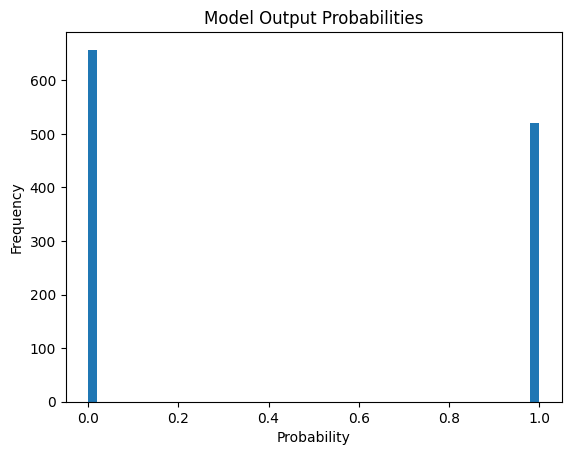

In [ ]:
import matplotlib.pyplot as plt

# 모델 예측 확률 분포 시각화
plt.hist(model_dnn_proba, bins=50)
plt.title("Model Output Probabilities")
plt.xlabel("Probability")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# 정확도, F1-score 등 지표 출력
print(classification_report(y_val1, y_pred_dnn))
print(confusion_matrix(y_val1, y_pred_dnn))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       657
           1       1.00      1.00      1.00       520

    accuracy                           1.00      1177
   macro avg       1.00      1.00      1.00      1177
weighted avg       1.00      1.00      1.00      1177

[[657   0]
 [  0 520]]


#### 6) 모델6 : SimpleRNN

In [ ]:
x_train_rnn = x_train1.reshape((x_train1.shape[0],x_train1.shape[1],1))
x_val_rnn = x_val1.reshape((x_val1.shape[0],x_val1.shape[1],1))

In [ ]:
n2 = x_train_rnn.shape[1]

In [ ]:
from keras.regularizers import l1,l2,l1_l2
from keras.layers import SimpleRNN

clear_session()

model_rnn = Sequential([
    SimpleRNN(128, activation = 'relu',input_shape=(n2,1),return_sequences = True,
              kernel_regularizer=l1_l2(l1=0.01,l2=0.01)),
    SimpleRNN(128, activation = 'relu',kernel_regularizer=l1_l2(l1=0.01,l2=0.01)),
    Dense(64, activation = 'relu',kernel_regularizer=l1_l2(l1=0.01,l2=0.01)),
    Dense(32, activation = 'relu',kernel_regularizer=l1_l2(l1=0.01,l2=0.01)),
    Dense(16, activation = 'relu',kernel_regularizer=l1_l2(l1=0.01,l2=0.01)),
    Dense(1, activation='sigmoid')

])

model_rnn.compile(optimizer=Adam(0.01),loss='binary_crossentropy',metrics=['accuracy'])

model_rnn.fit(x_train1,y_train1,epochs=50,batch_size=32,validation_split=.2,verbose=0)

model_rnn_proba = model_rnn.predict(x_val1)

y_pred_rnn = (model_rnn_proba > 0.5).astype(int)

# 정확도 계산
acc_rnn = accuracy_score(y_val1,y_pred_rnn)
print(f'RNN Model 정확도 : {acc_rnn}')

37/37 [==============================] - 2s 56ms/step
RNN Model 정확도 : 0.5581988105352591


In [ ]:
# 정확도, F1-score 등 지표 출력
print(classification_report(y_val1, y_pred_rnn))
print(confusion_matrix(y_val1, y_pred_rnn))


              precision    recall  f1-score   support

           0       0.56      1.00      0.72       657
           1       0.00      0.00      0.00       520

    accuracy                           0.56      1177
   macro avg       0.28      0.50      0.36      1177
weighted avg       0.31      0.56      0.40      1177

[[657   0]
 [520   0]]


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#### 7) 모델7 : LSTM

In [ ]:
from keras.layers import LSTM
from keras.callbacks import EarlyStopping

clear_session()

model_lstm = Sequential([
    LSTM(128, activation='relu', input_shape=(n2,1), return_sequences=True,
         kernel_regularizer=l1_l2(l1=0.01,l2=0.01)),
    LSTM(128, activation='relu', kernel_regularizer=l1_l2(l1=0.01,l2=0.01)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(optimizer=Adam(0.01),loss='binary_crossentropy',metrics=['accuracy'])

# EarlyStopping 설정 (val_loss가 3번 연속 개선되지 않으면 학습 중단)
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)


model_lstm.fit(x_train1,y_train1,epochs=50,batch_size=32,
               callbacks=[early_stopping],validation_split=.2,verbose=1)

model_lstm_proba = model_lstm.predict(x_val1)
y_pred_lstm = (model_rnn_proba > 0.5).astype(int)

# 정확도 계산
acc_lstm = accuracy_score(y_val1,y_pred_lstm)
print(f'RNN Model 정확도 : {acc_lstm}')

Epoch 1/50
118/118 [==============================] - 108s 894ms/step - loss: nan - accuracy: 0.5474 - val_loss: nan - val_accuracy: 0.5430
Epoch 2/50
118/118 [==============================] - 105s 894ms/step - loss: nan - accuracy: 0.5490 - val_loss: nan - val_accuracy: 0.5430
Epoch 3/50
37/37 [==============================] - 13s 332ms/step
RNN Model 정확도 : 0.5581988105352591


In [ ]:
# 정확도, F1-score 등 지표 출력
print(classification_report(y_val1, y_pred_lstm))
print(confusion_matrix(y_val1, y_pred_lstm))


              precision    recall  f1-score   support

           0       0.56      1.00      0.72       657
           1       0.00      0.00      0.00       520

    accuracy                           0.56      1177
   macro avg       0.28      0.50      0.36      1177
weighted avg       0.31      0.56      0.40      1177

[[657   0]
 [520   0]]


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#### 8) 모델8 : GRU

In [ ]:
from keras.layers import GRU

clear_session()

model_gru = Sequential([
    GRU(128, activation='relu', input_shape=(n2,1), return_sequences=True,
         kernel_regularizer=l1_l2(l1=0.01,l2=0.01)),
    GRU(128, activation='relu', kernel_regularizer=l1_l2(l1=0.01,l2=0.01)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_gru.compile(optimizer=Adam(0.01),loss='binary_crossentropy',metrics=['accuracy'])

model_gru.fit(x_train1,y_train1,epochs=50,batch_size=32,callbacks=[early_stopping],validation_split=.2,verbose=1)

model_gru_proba = model_gru.predict(x_val1)
y_pred_gru = (model_gru_proba > 0.5).astype(int)

# 정확도 계산
acc_gru = accuracy_score(y_val1,y_pred_gru)
print(f'RNN Model 정확도 : {acc_gru}')

Epoch 1/50
118/118 [==============================] - 78s 636ms/step - loss: 2.9371 - accuracy: 0.5490 - val_loss: 1.3709 - val_accuracy: 0.5430
Epoch 2/50
118/118 [==============================] - 74s 631ms/step - loss: 1.3463 - accuracy: 0.5490 - val_loss: 1.3356 - val_accuracy: 0.5430
Epoch 3/50
118/118 [==============================] - 74s 626ms/step - loss: 1.3546 - accuracy: 0.5490 - val_loss: 1.3574 - val_accuracy: 0.5430
Epoch 4/50
118/118 [==============================] - 74s 627ms/step - loss: 1.3574 - accuracy: 0.5490 - val_loss: 1.3616 - val_accuracy: 0.5430
Epoch 5/50
37/37 [==============================] - 6s 160ms/step
RNN Model 정확도 : 0.5581988105352591


In [ ]:
# 정확도, F1-score 등 지표 출력
print(classification_report(y_val1, y_pred_gru))
print(confusion_matrix(y_val1, y_pred_gru))


              precision    recall  f1-score   support

           0       0.56      1.00      0.72       657
           1       0.00      0.00      0.00       520

    accuracy                           0.56      1177
   macro avg       0.28      0.50      0.36      1177
weighted avg       0.31      0.56      0.40      1177

[[657   0]
 [520   0]]


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### 모델별 성능 비교

In [ ]:
print(f'Logistic Regression Accuracy: {accuracy_lr}')
print(f'RandomForest 정확도 : {acc_rf}')
print(f'Gradient Boosting 정확도 : {acc_gb}')
print(f'SVM(RBF커널) 정확도 : {acc_svm_rbf}')
print(f'K-NN 정확도 : {acc_knn}')
print(f'DNN Model 정확도 : {acc_dnn}')
print(f'RNN Model 정확도 : {acc_rnn}')

Logistic Regression Accuracy: 1.0
RandomForest 정확도 : 1.0
Gradient Boosting 정확도 : 0.9974511469838573
SVM(RBF커널) 정확도 : 1.0
K-NN 정확도 : 1.0
DNN Model 정확도 : 1.0
RNN Model 정확도 : 0.5581988105352591


### (2) 단계2

#### 1) 단계2-1 : 정적 동작 세부 분류

* 세부 요구사항
    * 정적 행동(Laying, Sitting, Standing)인 데이터 추출
    * Laying, Sitting, Standing 를 분류하는 모델을 생성
    * 몇가지 모델을 만들고 가장 성능이 좋은 모델을 선정하시오.

In [ ]:
# 정적 행동 데이터 추출

# 정작 행동에 해당하는 List 생성
static_act = ['LAYING','SITTING','STANDING']

# train_data에서 정적인 행동을 추출하는 코드
static_data = train_data[train_data['Activity'].isin(static_act)]
# train_data['Activiry] : Activity열에 있는 활동을 가리킴
# .isin(static_act) : 열의 값이 static_act 리스트 값과 일치하는지 여부를 반환하는 함수
# 즉 정적에 해당하는 데이터만 필터링하는 것이다.
# => LAYING,SITTING,STANDING 데이터만 포함한 DataFrame이된다.

# x,y 분리
x_static = static_data.drop(target,axis=1)
y_static = static_data.loc[:,target]

In [ ]:
# 전처리 (MinMAxScaler)
scaler = MinMaxScaler()
x_static_s = scaler.fit_transform(x_static)

# LabelEncoder
encoder = LabelEncoder()
y_static_enc = encoder.fit_transform(y_static)

# train,validation 분리
x_train_1,x_val_1,y_train_1,y_val_1 = train_test_split(x_static_s,y_static_enc,test_size=0.2,random_state=42)

#### 추가 모델 : 로지스틱 회귀

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 로지스틱 회귀 모델 학습
model_lr_1 = LogisticRegression(random_state=42)
model_lr_1.fit(x_train_1, y_train_1)

# 검증 데이터 성능 평가
y_pred_lr_1 = model_lr_1.predict(x_val_1)
accuracy_lr_1 = accuracy_score(y_val_1, y_pred_lr_1)
print(f'Logistic Regression Accuracy: {accuracy_lr_1}')

Logistic Regression Accuracy: 0.9752704791344667


In [ ]:
# 정확도, F1-score 등 지표 출력
print(classification_report(y_val_1, y_pred_lr_1))
print(confusion_matrix(y_val_1, y_pred_lr_1))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       221
           1       0.96      0.97      0.96       205
           2       0.97      0.96      0.96       221

    accuracy                           0.98       647
   macro avg       0.97      0.98      0.97       647
weighted avg       0.98      0.98      0.98       647

[[221   0   0]
 [  0 198   7]
 [  0   9 212]]


#### 1) 모델1 : 랜덤 포레스트

In [ ]:
model_rf_1 = RandomForestClassifier(random_state=42,max_depth=5)
model_rf_1.fit(x_train_1,y_train_1)

y_pred_rf_1 = model_rf_1.predict(x_val_1)
acc_rf_1 = accuracy_score(y_val_1,y_pred_rf_1)
print(f'RandomForest 정확도 : {acc_rf_1}')

RandomForest 정확도 : 0.9582689335394127


In [ ]:
# 정확도, F1-score 등 지표 출력
print(classification_report(y_val_1, y_pred_rf_1))
print(confusion_matrix(y_val_1, y_pred_rf_1))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       221
           1       0.92      0.95      0.94       205
           2       0.95      0.92      0.94       221

    accuracy                           0.96       647
   macro avg       0.96      0.96      0.96       647
weighted avg       0.96      0.96      0.96       647

[[221   0   0]
 [  0 195  10]
 [  0  17 204]]


#### 2) 모델2 : Gradient Boosting

In [ ]:
model_gb_1 = GradientBoostingClassifier(random_state=42,
                                        learning_rate=0.1,max_depth=5)
model_gb_1.fit(x_train_1,y_train_1)

y_pred_gb_1 = model_gb_1.predict(x_val_1)
acc_gb_1 = accuracy_score(y_val_1,y_pred_gb_1)
print(f'Gradient Boosting 정확도 : {acc_gb_1} ')

Gradient Boosting 정확도 : 0.9799072642967542 


In [ ]:
# 정확도, F1-score 등 지표 출력
print(classification_report(y_val_1, y_pred_gb_1))
print(confusion_matrix(y_val_1, y_pred_gb_1))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       221
           1       0.97      0.97      0.97       205
           2       0.97      0.97      0.97       221

    accuracy                           0.98       647
   macro avg       0.98      0.98      0.98       647
weighted avg       0.98      0.98      0.98       647

[[221   0   0]
 [  0 199   6]
 [  0   7 214]]


#### 3) 모델3 : RBF커널 사용한 SVM

In [ ]:
from sklearn.svm import SVC

model_svm_rbf_1 = SVC(kernel='rbf',random_state=42)
model_svm_rbf_1.fit(x_train_1,y_train_1)

y_pred_svm_rbf_1 = model_svm_rbf_1.predict(x_val_1)
acc_svm_rbf_1 = accuracy_score(y_val_1,y_pred_svm_rbf_1)
print(f'SVM(RBF커널) 정확도 : {acc_svm_rbf_1}')

SVM(RBF커널) 정확도 : 0.955177743431221


In [ ]:
# 정확도, F1-score 등 지표 출력
print(classification_report(y_val_1, y_pred_svm_rbf_1))
print(confusion_matrix(y_val_1, y_pred_svm_rbf_1))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       221
           1       0.93      0.93      0.93       205
           2       0.94      0.93      0.94       221

    accuracy                           0.96       647
   macro avg       0.95      0.95      0.95       647
weighted avg       0.96      0.96      0.96       647

[[221   0   0]
 [  1 191  13]
 [  0  15 206]]


#### 4) 모델4 : KNN

In [ ]:
from sklearn.model_selection import GridSearchCV

# KNN 하이퍼파라미터 그리드 설정
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],  # 다양한 k 값 탐색
    'weights': ['uniform', 'distance'],  # 가중치 설정
    'metric': ['euclidean', 'manhattan']  # 거리 측정 방법
}

# GridSearchCV 사용
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid_search.fit(x_train_1, y_train_1)

# 최적 하이퍼파라미터 출력
print(f'Best parameters: {grid_search.best_params_}')

# 검증 데이터에서 성능 확인
y_pred_knn_best = grid_search.predict(x_val_1)
acc_knn_best = accuracy_score(y_val_1, y_pred_knn_best)
print(f'K-NN 최적 모델 정확도 : {acc_knn_best}')

Best parameters: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
K-NN 최적 모델 정확도 : 0.955177743431221


In [ ]:
# 정확도, F1-score 등 지표 출력
print(classification_report(y_val_1, y_pred_knn_best))
print(confusion_matrix(y_val_1, y_pred_knn_best))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       221
           1       0.96      0.89      0.93       205
           2       0.91      0.97      0.94       221

    accuracy                           0.96       647
   macro avg       0.96      0.95      0.95       647
weighted avg       0.96      0.96      0.95       647

[[221   0   0]
 [  1 183  21]
 [  0   7 214]]


#### 5) 모델5 : DNN

In [ ]:
n1 = x_train_1.shape[1]

In [ ]:
clear_session()

model_dnn_1 = Sequential([
    Dense(128, activation='relu',input_shape=(n,)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.1),
    Dense(16, activation='relu'),
    Dense(3, activation='softmax')
])

model_dnn_1.compile(optimizer=Adam(0.001),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

model_dnn_1.fit(x_train_1,y_train_1,epochs=100,callbacks=[early_stopping],batch_size=32,validation_split=0.2,verbose=1)

# 모델 예측
model_dnn_proba_1 = model_dnn_1.predict(x_val_1)

# 다중 클래스 분류에서 가장 높은 확률을 가진 클래스를 선택
y_pred_dnn_1 = np.argmax(model_dnn_proba_1, axis=1)

# 정확도 계산
acc_dnn_1 = accuracy_score(y_val_1, y_pred_dnn_1)
print(f'DNN Model 정확도 : {acc_dnn_1}')

Epoch 1/100
65/65 [==============================] - 1s 7ms/step - loss: 0.8022 - accuracy: 0.6216 - val_loss: 0.4685 - val_accuracy: 0.7741
Epoch 2/100
65/65 [==============================] - 0s 4ms/step - loss: 0.4410 - accuracy: 0.7917 - val_loss: 0.3366 - val_accuracy: 0.8552
Epoch 3/100
65/65 [==============================] - 0s 4ms/step - loss: 0.3531 - accuracy: 0.8478 - val_loss: 0.2851 - val_accuracy: 0.8938
Epoch 4/100
65/65 [==============================] - 0s 4ms/step - loss: 0.2768 - accuracy: 0.8898 - val_loss: 0.2120 - val_accuracy: 0.9131
Epoch 5/100
65/65 [==============================] - 0s 4ms/step - loss: 0.2829 - accuracy: 0.8903 - val_loss: 0.2947 - val_accuracy: 0.8649
Epoch 6/100
65/65 [==============================] - 0s 4ms/step - loss: 0.2262 - accuracy: 0.9058 - val_loss: 0.1666 - val_accuracy: 0.9344
Epoch 7/100
65/65 [==============================] - 0s 4ms/step - loss: 0.1921 - accuracy: 0.9232 - val_loss: 0.1670 - val_accuracy: 0.9344
Epoch 8/100
6

In [ ]:
# 정확도, F1-score 등 지표 출력
print(classification_report(y_val_1, y_pred_dnn_1))
print(confusion_matrix(y_val_1, y_pred_dnn_1))


              precision    recall  f1-score   support

           0       0.99      1.00      1.00       221
           1       0.91      0.94      0.93       205
           2       0.95      0.91      0.93       221

    accuracy                           0.95       647
   macro avg       0.95      0.95      0.95       647
weighted avg       0.95      0.95      0.95       647

[[221   0   0]
 [  2 193  10]
 [  0  19 202]]


#### 6) 모델6 : SimpleRNN

In [ ]:
# 올바른 차원으로 재구성 (timesteps = 1로 설정)
x_train_rnn_1 = x_train_1.reshape((x_train_1.shape[0], 1, x_train_1.shape[1]))
x_val_rnn_1 = x_val_1.reshape((x_val_1.shape[0], 1, x_val_1.shape[1]))

(2587, 561)
(647, 561)
(2587, 1, 561)
(647, 1, 561)


In [ ]:
n2_1 = x_train_rnn_1.shape[1]

In [ ]:
clear_session()

# RNN 모델 정의
model_rnn_1 = Sequential([
    SimpleRNN(128, activation='relu', input_shape=(1, 561), return_sequences=True,
              kernel_regularizer=l1_l2(l1=0.01, l2=0.01)),
    SimpleRNN(128, activation='relu', kernel_regularizer=l1_l2(l1=0.01, l2=0.01)),
    Dense(64, activation='relu', kernel_regularizer=l1_l2(l1=0.01, l2=0.01)),
    Dense(32, activation='relu', kernel_regularizer=l1_l2(l1=0.01, l2=0.01)),
    Dense(16, activation='relu', kernel_regularizer=l1_l2(l1=0.01, l2=0.01)),
    Dense(3, activation='softmax')
])

# 모델 컴파일
model_rnn_1.compile(optimizer=Adam(0.01), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 모델 학습 (RNN 입력 형태인 x_train_rnn_1 사용)
model_rnn_1.fit(x_train_rnn_1, y_train_1, epochs=50, batch_size=32, callbacks=[early_stopping], validation_split=0.2, verbose=1)

# 검증 데이터 예측 (x_val_rnn_1 사용)
model_rnn_proba_1 = model_rnn_1.predict(x_val_rnn_1)

# 예측된 클래스 값 변환
y_pred_rnn_1 = np.argmax(model_rnn_proba_1, axis=1)

# 정확도 계산
acc_rnn_1 = accuracy_score(y_val_1, y_pred_rnn_1)
print(f'RNN Model 정확도 : {acc_rnn_1}')


Epoch 1/50
65/65 [==============================] - 3s 11ms/step - loss: 9.1289 - accuracy: 0.3461 - val_loss: 2.5351 - val_accuracy: 0.3707
Epoch 2/50
65/65 [==============================] - 0s 5ms/step - loss: 2.4156 - accuracy: 0.3238 - val_loss: 2.4129 - val_accuracy: 0.3707
Epoch 3/50
65/65 [==============================] - 0s 5ms/step - loss: 2.3714 - accuracy: 0.3369 - val_loss: 2.3661 - val_accuracy: 0.3707
Epoch 4/50
65/65 [==============================] - 0s 5ms/step - loss: 2.3813 - accuracy: 0.3393 - val_loss: 2.4001 - val_accuracy: 0.3707
Epoch 5/50
65/65 [==============================] - 0s 5ms/step - loss: 2.3922 - accuracy: 0.3378 - val_loss: 2.3371 - val_accuracy: 0.3707
Epoch 6/50
65/65 [==============================] - 0s 5ms/step - loss: 2.3938 - accuracy: 0.3456 - val_loss: 2.4152 - val_accuracy: 0.3050
Epoch 7/50
65/65 [==============================] - 0s 5ms/step - loss: 2.3952 - accuracy: 0.3291 - val_loss: 2.4188 - val_accuracy: 0.3050
Epoch 8/50
21/21 [=

In [ ]:
# 정확도, F1-score 등 지표 출력
print(classification_report(y_val_1, y_pred_rnn_1))
print(confusion_matrix(y_val_1, y_pred_rnn_1))


              precision    recall  f1-score   support

           0       0.34      1.00      0.51       221
           1       0.00      0.00      0.00       205
           2       0.00      0.00      0.00       221

    accuracy                           0.34       647
   macro avg       0.11      0.33      0.17       647
weighted avg       0.12      0.34      0.17       647

[[221   0   0]
 [205   0   0]
 [221   0   0]]


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### 결론 : 시계열 모델(대표적으로 SimpleRNN)은 현재 데이터셋에서는 다른 비선형 모델과 DNN모델, 심지어 선형모델보다 성능이 안나오는 것을 확인할 수 있다.

In [ ]:
print(f'Logistic Regression 정확도 : {accuracy_lr_1}')
print('-'*30)
print(f'Gradient Boosting 정확도 : {acc_gb_1} ')
print(f'SVM(RBF커널) 정확도 : {acc_svm_rbf_1}')
print(f'K-NN 최적 모델 정확도 : {acc_knn_best}')
print('-'*30)
print(f'DNN Model 정확도 : {acc_dnn_1}')
print('-'*30)
print(f'RNN Model 정확도 : {acc_rnn_1}')

Logistic Regression 정확도 : 0.9752704791344667
------------------------------
Gradient Boosting 정확도 : 0.9799072642967542 
SVM(RBF커널) 정확도 : 0.955177743431221
K-NN 최적 모델 정확도 : 0.955177743431221
------------------------------
DNN Model 정확도 : 0.9520865533230294
------------------------------
RNN Model 정확도 : 0.3415765069551777


#### 2) 단계2-2 : 동적 동작 세부 분류

* 세부 요구사항
    * 동동적 행동(Walking, Walking Upstairs, Walking Downstairs)인 데이터 추출
    * Walking, Walking Upstairs, Walking Downstairs 를 분류하는 모델을 생성
    * 몇가지 모델을 만들고 가장 성능이 좋은 모델을 선정하시오.

In [ ]:
y

,Activity
0,STANDING
1,LAYING
2,STANDING
3,WALKING
4,WALKING_DOWNSTAIRS
...,...
5876,SITTING
5877,WALKING_UPSTAIRS
5878,LAYING
5879,WALKING_UPSTAIRS


In [ ]:
# 동적 행동 데이터 추출

# 동적 행동에 해당하는 List 생성
dynamic_act = ['WALKING','WALKING_UPSTAIRS','WALKING_DOWNSTAIRS']

# train_data에서 동적인 행동을 추출하는 코드
dynamic_data = train_data[train_data['Activity'].isin(dynamic_act)]


# x,y 분리"
x_dynamic = dynamic_data.drop(target,axis=1)
y_dynamic = dynamic_data.loc[:,target]

In [ ]:
# 전처리 (MinMAxScaler)
scaler = MinMaxScaler()
x_dynamic_s = scaler.fit_transform(x_static)

# LabelEncoder
encoder = LabelEncoder()
y_dynamic_enc = encoder.fit_transform(y_static)

# train,validation 분리
x_train_2,x_val_2,y_train_2,y_val_2 = train_test_split(x_dynamic_s,y_dynamic_enc,test_size=0.3,random_state=42)

#### 추가 모델 : 로지스틱 회귀

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 로지스틱 회귀 모델 학습
model_lr_2 = LogisticRegression(random_state=42)
model_lr_2.fit(x_train_2, y_train_2)

# 검증 데이터 성능 평가
y_pred_lr_2 = model_lr_2.predict(x_val_2)
accuracy_lr_2 = accuracy_score(y_val_2, y_pred_lr_2)
print(f'Logistic Regression Accuracy: {accuracy_lr_2}')

Logistic Regression Accuracy: 0.9752704791344667


In [ ]:
# 정확도, F1-score 등 지표 출력
print(classification_report(y_val_2, y_pred_lr_2))
print(confusion_matrix(y_val_2, y_pred_lr_2))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       221
           1       0.96      0.97      0.96       205
           2       0.97      0.96      0.96       221

    accuracy                           0.98       647
   macro avg       0.97      0.98      0.97       647
weighted avg       0.98      0.98      0.98       647

[[221   0   0]
 [  0 198   7]
 [  0   9 212]]


#### 1) 모델1 : 랜덤 포레스트

In [ ]:
model_rf_2 = RandomForestClassifier(random_state=42,max_depth=5)
model_rf_2.fit(x_train_2,y_train_2)

y_pred_rf_2 = model_rf_1.predict(x_val_2)
acc_rf_2 = accuracy_score(y_val_2,y_pred_rf_2)
print(f'RandomForest 정확도 : {acc_rf_2}')

RandomForest 정확도 : 0.9582689335394127


In [ ]:
# 정확도, F1-score 등 지표 출력
print(classification_report(y_val_2, y_pred_rf_2))
print(confusion_matrix(y_val_2, y_pred_rf_2))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       221
           1       0.92      0.95      0.94       205
           2       0.95      0.92      0.94       221

    accuracy                           0.96       647
   macro avg       0.96      0.96      0.96       647
weighted avg       0.96      0.96      0.96       647

[[221   0   0]
 [  0 195  10]
 [  0  17 204]]


#### 2) 모델2 : Gradient Boosting

In [ ]:
model_gb_2 = GradientBoostingClassifier(random_state=42,
                                        learning_rate=0.1,max_depth=5)
model_gb_2.fit(x_train_2,y_train_2)

y_pred_gb_2 = model_gb_2.predict(x_val_2)
acc_gb_2 = accuracy_score(y_val_2,y_pred_gb_2)
print(f'Gradient Boosting 정확도 : {acc_gb_2} ')

Gradient Boosting 정확도 : 0.9799072642967542 


In [ ]:
# 정확도, F1-score 등 지표 출력
print(classification_report(y_val_2, y_pred_gb_2))
print(confusion_matrix(y_val_2, y_pred_gb_2))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       221
           1       0.97      0.97      0.97       205
           2       0.97      0.97      0.97       221

    accuracy                           0.98       647
   macro avg       0.98      0.98      0.98       647
weighted avg       0.98      0.98      0.98       647

[[221   0   0]
 [  0 199   6]
 [  0   7 214]]


#### 3) 모델3 : RBF커널 사용한 SVM

In [ ]:
from sklearn.svm import SVC

model_svm_rbf_2 = SVC(kernel='rbf',random_state=42)
model_svm_rbf_2.fit(x_train_2,y_train_2)

y_pred_svm_rbf_2 = model_svm_rbf_2.predict(x_val_2)
acc_svm_rbf_2 = accuracy_score(y_val_2,y_pred_svm_rbf_2)
print(f'SVM(RBF커널) 정확도 : {acc_svm_rbf_2}')

SVM(RBF커널) 정확도 : 0.955177743431221


In [ ]:
# 정확도, F1-score 등 지표 출력
print(classification_report(y_val_2, y_pred_svm_rbf_2))
print(confusion_matrix(y_val_2, y_pred_svm_rbf_2))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       221
           1       0.93      0.93      0.93       205
           2       0.94      0.93      0.94       221

    accuracy                           0.96       647
   macro avg       0.95      0.95      0.95       647
weighted avg       0.96      0.96      0.96       647

[[221   0   0]
 [  1 191  13]
 [  0  15 206]]


#### 4) 모델4 : KNN

In [ ]:
from sklearn.model_selection import GridSearchCV

# KNN 하이퍼파라미터 그리드 설정
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],  # 다양한 k 값 탐색
    'weights': ['uniform', 'distance'],  # 가중치 설정
    'metric': ['euclidean', 'manhattan']  # 거리 측정 방법
}

# GridSearchCV 사용
grid_search_1 = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid_search_1.fit(x_train_2, y_train_2)

# 최적 하이퍼파라미터 출력
print(f'Best parameters: {grid_search.best_params_}')

# 검증 데이터에서 성능 확인
y_pred_knn_best_1 = grid_search_1.predict(x_val_2)
acc_knn_best_1 = accuracy_score(y_val_2, y_pred_knn_best_1)
print(f'K-NN 최적 모델 정확도 : {acc_knn_best_1}')

Best parameters: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
K-NN 최적 모델 정확도 : 0.955177743431221


In [ ]:
# 정확도, F1-score 등 지표 출력
print(classification_report(y_val_2, y_pred_knn_best_1))
print(confusion_matrix(y_val_2, y_pred_knn_best_1))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       221
           1       0.96      0.89      0.93       205
           2       0.91      0.97      0.94       221

    accuracy                           0.96       647
   macro avg       0.96      0.95      0.95       647
weighted avg       0.96      0.96      0.95       647

[[221   0   0]
 [  1 183  21]
 [  0   7 214]]


#### 5) 모델5 : DNN

In [ ]:
n1_1 = x_train_2.shape[1]

In [ ]:
# clear_session()

# model_dnn_2 = Sequential([
#     Dense(128, activation='relu',input_shape=(n,)),
#     Dropout(0.3),
#     Dense(64, activation='relu'),
#     Dropout(0.2),
#     Dense(32, activation='relu'),
#     Dropout(0.1),
#     Dense(16, activation='relu'),
#     Dense(3, activation='softmax')
# ])

# model_dnn_2.compile(optimizer=Adam(0.001),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

# model_dnn_2.fit(x_train_2,y_train_2,epochs=100,callbacks=[early_stopping],batch_size=32,validation_split=0.2,verbose=0)

# # 모델 예측
# model_dnn_proba_2 = model_dnn_2.predict(x_val_2)

# # 다중 클래스 분류에서 가장 높은 확률을 가진 클래스를 선택
# y_pred_dnn_2 = np.argmax(model_dnn_proba_2, axis=1)

# # 정확도 계산
# acc_dnn_2 = accuracy_score(y_val_2, y_pred_dnn_2)
# print(f'DNN Model 정확도 : {acc_dnn_2}')

31/31 [==============================] - 0s 2ms/step
DNN Model 정확도 : 0.956745623069001


In [ ]:
clear_session()

model_dnn_2 = Sequential([
    Dense(64, activation='relu',input_shape=(n,)),
    Dense(16, activation='relu'),
    Dense(3, activation='softmax')
])

model_dnn_2.compile(optimizer=Adam(0.001),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

min_de = 0.0001
pat = 15
es = EarlyStopping(monitor ='val_loss', min_delta = min_de, patience = pat)

model_dnn_2.fit(x_train_2, y_train_2, epochs=100, validation_split=0.2, verbose=0, callbacks=[es])

# 모델 예측
model_dnn_proba_2 = model_dnn_2.predict(x_val_2)

# 다중 클래스 분류에서 가장 높은 확률을 가진 클래스를 선택
y_pred_dnn_2 = np.argmax(model_dnn_proba_2, axis=1)

# 정확도 계산
acc_dnn_2 = accuracy_score(y_val_2, y_pred_dnn_2)
print(f'DNN Model 정확도 : {acc_dnn_2}')

31/31 [==============================] - 0s 1ms/step
DNN Model 정확도 : 0.976313079299691


In [ ]:
clear_session()

model_dnn_3 = Sequential([
                     Dense(256,input_shape=(n,),activation='relu'),
                     Dropout(0.3),
                     Dense(128, activation = 'relu'),
                     Dropout(0.3),
                     Dense(64, activation = 'relu'),
                     Dense(32, activation = 'relu'),
                     Dense(16, activation = 'relu'),
                     Dense(8, activation='relu'),
                     Dense(3, activation = 'softmax')])

model_dnn_3.compile(optimizer=Adam(learning_rate = 0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# Early Stopping 적용
early_stopping = EarlyStopping(monitor='val_loss', patience=15)

model_dnn_3.fit(x_train_2, y_train_2, epochs=200,verbose=0, validation_split=0.2, callbacks=[early_stopping])

model_dnn_proba_3 = model_dnn_3.predict(x_val_2)

y_pred_dnn_3 = np.argmax(model_dnn_proba_3, axis=1)

acc_dnn_3 = accuracy_score(y_val_2,y_pred_dnn_3)
print(f'DNN Model 정확도 : {acc_dnn_3}')

31/31 [==============================] - 0s 2ms/step
DNN Model 정확도 : 0.9701338825952626


In [ ]:
# 정확도, F1-score 등 지표 출력
print(classification_report(y_val_2, y_pred_dnn_2))
print(confusion_matrix(y_val_2, y_pred_dnn_2))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       221
           1       0.92      0.95      0.93       205
           2       0.95      0.92      0.93       221

    accuracy                           0.96       647
   macro avg       0.95      0.95      0.95       647
weighted avg       0.96      0.96      0.96       647

[[221   0   0]
 [  0 194  11]
 [  0  18 203]]


#### 6) 모델6 : SimpleRNN

In [ ]:
# 올바른 차원으로 재구성 (timesteps = 1로 설정)
x_train_rnn_2 = x_train_2.reshape((x_train_2.shape[0], 1, x_train_2.shape[1]))
x_val_rnn_2 = x_val_2.reshape((x_val_2.shape[0], 1, x_val_2.shape[1]))

In [ ]:
n2_2 = x_train_rnn_2.shape[1]

In [ ]:
clear_session()

# RNN 모델 정의
model_rnn_2 = Sequential([
    SimpleRNN(128, activation='relu', input_shape=(1, 561), return_sequences=True,
              kernel_regularizer=l1_l2(l1=0.01, l2=0.01)),
    SimpleRNN(128, activation='relu', kernel_regularizer=l1_l2(l1=0.01, l2=0.01)),
    Dense(64, activation='relu', kernel_regularizer=l1_l2(l1=0.01, l2=0.01)),
    Dense(32, activation='relu', kernel_regularizer=l1_l2(l1=0.01, l2=0.01)),
    Dense(16, activation='relu', kernel_regularizer=l1_l2(l1=0.01, l2=0.01)),
    Dense(3, activation='softmax')
])

# 모델 컴파일
model_rnn_2.compile(optimizer=Adam(0.01), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 모델 학습
model_rnn_2.fit(x_train_rnn_1, y_train_2, epochs=50, batch_size=32, callbacks=[early_stopping], validation_split=0.2, verbose=1)

# 검증 데이터 예측
model_rnn_proba_2 = model_rnn_2.predict(x_val_rnn_2)

# 예측된 클래스 값 변환
y_pred_rnn_2 = np.argmax(model_rnn_proba_2, axis=1)

# 정확도 계산
acc_rnn_2 = accuracy_score(y_val_2, y_pred_rnn_2)
print(f'RNN Model 정확도 : {acc_rnn_2}')


Epoch 1/50
65/65 [==============================] - 3s 12ms/step - loss: 9.1291 - accuracy: 0.3306 - val_loss: 2.5571 - val_accuracy: 0.3050
Epoch 2/50
65/65 [==============================] - 0s 5ms/step - loss: 2.4201 - accuracy: 0.3325 - val_loss: 2.4241 - val_accuracy: 0.3050
Epoch 3/50
65/65 [==============================] - 0s 5ms/step - loss: 2.3780 - accuracy: 0.3311 - val_loss: 2.3772 - val_accuracy: 0.3050
Epoch 4/50
65/65 [==============================] - 0s 5ms/step - loss: 2.3890 - accuracy: 0.3296 - val_loss: 2.4136 - val_accuracy: 0.3050
Epoch 5/50
65/65 [==============================] - 0s 5ms/step - loss: 2.4002 - accuracy: 0.3229 - val_loss: 2.3356 - val_accuracy: 0.3050
Epoch 6/50
65/65 [==============================] - 0s 5ms/step - loss: 2.4023 - accuracy: 0.3311 - val_loss: 2.4242 - val_accuracy: 0.3050
Epoch 7/50
65/65 [==============================] - 0s 5ms/step - loss: 2.4019 - accuracy: 0.3432 - val_loss: 2.4308 - val_accuracy: 0.3707
Epoch 8/50
21/21 [=

In [ ]:
# 정확도, F1-score 등 지표 출력
print(classification_report(y_val_2, y_pred_rnn_2))
print(confusion_matrix(y_val_2, y_pred_rnn_2))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00       221
           1       0.00      0.00      0.00       205
           2       0.34      1.00      0.51       221

    accuracy                           0.34       647
   macro avg       0.11      0.33      0.17       647
weighted avg       0.12      0.34      0.17       647

[[  0   0 221]
 [  0   0 205]
 [  0   0 221]]


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
print(f'Logistic Regression 정확도 : {accuracy_lr_2}')
print('-'*30)
print(f'Gradient Boosting 정확도 : {acc_gb_2} ')
print(f'SVM(RBF커널) 정확도 : {acc_svm_rbf_2}')
print(f'K-NN 최적 모델 정확도 : {acc_knn_best_1}')
print('-'*30)
print(f'DNN Model 정확도 : {acc_dnn_2}')
print('-'*30)
print(f'RNN Model 정확도 : {acc_rnn_2}')

Logistic Regression 정확도 : 0.9752704791344667
------------------------------
Gradient Boosting 정확도 : 0.9799072642967542 
SVM(RBF커널) 정확도 : 0.955177743431221
K-NN 최적 모델 정확도 : 0.955177743431221
------------------------------
DNN Model 정확도 : 0.955177743431221
------------------------------
RNN Model 정확도 : 0.3415765069551777


### (3) 분류 모델 파이프라인 구성


* 세부 요구사항
    * 두 단계 모델을 통합하고, 새로운 데이터(test)에 대해서 최종 예측결과와 성능평가가 나오도록 함수로 만들기
    * 데이터 파이프라인 구축 : test데이터가 로딩되어 전처리 과정을 거치고, 예측 및 성능 평가 수행

* 예시
![](https://github.com/DA4BAM/image/blob/main/pipeline%20function.png?raw=true)

#### 1) 함수 만들기

In [ ]:
def act_classification_pipeline(test_data, model_stage, model_static, model_dynamic):
    # is_dynamic = y.map({'STANDING':0, 'SITTING':0, 'LAYING':0,
    #               'WALKING':1, 'WALKING_UPSTAIRS':1, 'WALKING_DOWNSTAIRS':1})
    # 1. 데이터 전처리
    print("Step 1: 데이터 전처리 시작")
    x_test = test_data.drop(columns=target)  # Activity 제거
    y_test = test_data.loc[:, target]

    # 데이터 스케일링 (MinMaxScaler 사용)
    #scaler = MinMaxScaler()
    #x_test_s = scaler.fit_transform(x_test)
    x_test_s = scaler1.transform(x_test)
    print(f"x_test_s shape: {x_test_s.shape}")
    print(f"y_test shape: {y_test.shape}")

    # 2. 정적 / 동적 분류
    print("Step 2: 정적 / 동적 분류 시작")
    is_dynamic_proba = model_stage.predict(x_test_s)
    is_dynamic = np.where(is_dynamic_proba>0.5, 1, 0)
    print(f"is_dynamic 분류 결과 (0: 정적, 1: 동적): {np.unique(is_dynamic, return_counts=True)}")

    # 3 - 1. 정적 행동 분류
    static_indices = (is_dynamic == 0)
    print(static_indices)
    print(x_test_s)
    x_test_static = x_test_s[static_indices, :]
    y_test_static = y_test[static_indices]
    print(f"x_test_static shape: {x_test_static.shape}, y_test_static shape: {y_test_static.shape}")

    if len(x_test_static) > 0:
        # 정적 행동에 대한 예측
        y_pred_static_proba = model_static.predict(x_test_static)
        y_pred_static = np.argmax(y_pred_static_proba, axis=1)  # 각 행에 대해 최대값 선택

        # 정적 행동 예측 결과를 라벨로 변환
        y_pred_static_labels = [ ['LAYING', 'SITTING', 'STANDING'][i] for i in y_pred_static ]

        # 정확도 계산
        static_acc = accuracy_score(y_test_static, y_pred_static_labels)
        print(f'정적 행동 정확도: {static_acc}')
    else:
        y_pred_static_labels = []
        print("정적 행동 데이터가 없습니다.")

    # 3 - 2. 동적 행동 분류
    dynamic_indices = (is_dynamic == 1)
    x_test_dynamic = x_test_s[dynamic_indices, :]
    y_test_dynamic = y_test[dynamic_indices]
    print(x_test_dynamic)
    if len(x_test_dynamic) > 0:
        # 동적 행동에 대한 예측
        y_pred_dynamic_proba = model_dynamic.predict(x_test_dynamic)
        y_pred_dynamic = np.argmax(y_pred_dynamic_proba, axis=1)  # 각 행에 대해 최대값 선택

        # 동적 행동 예측 결과를 라벨로 변환
        y_pred_dynamic_labels = [ ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS'][i] for i in y_pred_dynamic ]

        # 정확도 계산
        dynamic_acc = accuracy_score(y_test_dynamic, y_pred_dynamic_labels)
        print(f'동적 행동 정확도: {dynamic_acc}')
    else:
        y_pred_dynamic_labels = []
        print("동적 행동 데이터가 없습니다.")

    # 4. 예측 결과 합치기
    final_pred = np.zeros_like(is_dynamic, dtype=object)

    if len(y_pred_static_labels) > 0:
        final_pred[static_indices] = y_pred_static_labels
    if len(y_pred_dynamic_labels) > 0:
        final_pred[dynamic_indices] = y_pred_dynamic_labels

    # 5. 전체적인 성능 평가
    overall_acc = accuracy_score(y_test, final_pred)
    print(f'전체 모델 정확도: {overall_acc}')
    print(classification_report(y_test, final_pred))
    print(confusion_matrix(y_test, final_pred))

    return final_pred


#### 2) test 셋으로 예측하고 평가하기

In [ ]:
# 모델1: 정적/동적 분류 모델
model_stage = model_dnn

# 모델2-1: 정적 행동 (Laying, Sitting, Standing) 분류 모델
model_static = model_dnn_1

# 모델2-2: 동적 행동 (Walking, Walking-Upstairs, Walking-Downstairs) 분류 모델
model_dynamic = model_dnn_2

# 테스트 데이터 불러오기
test_data

# 파이프라인 함수 실행
final_pred = act_classification_pipeline(test_data, model_stage, model_static, model_dynamic)


Step 1: 데이터 전처리 시작
x_test_s shape: (1471, 561)
y_test shape: (1471,)
Step 2: 정적 / 동적 분류 시작
46/46 [==============================] - 0s 2ms/step
is_dynamic 분류 결과 (0: 정적, 1: 동적): (array([0, 1]), array([833, 638]))
[[ True]
 [ True]
 [False]
 ...
 [False]
 [ True]
 [False]]
[[0.52413202 0.39344493 0.44165847 ... 0.1659081  0.6641034  0.40118811]
 [0.51951767 0.3898215  0.44079416 ... 0.08758391 0.80132807 0.46029197]
 [0.53839805 0.38214312 0.45634832 ... 0.12985394 0.86065652 0.52180263]
 ...
 [0.49488882 0.4102658  0.43931152 ... 0.1822828  0.8019197  0.62639128]
 [0.42537996 0.39421957 0.441678   ... 0.90569819 0.35543065 0.23947262]
 [0.49566059 0.39453407 0.45807091 ... 0.09660213 0.80772682 0.4562184 ]]


IndexError: too many indices for array: array is 2-dimensional, but 3 were indexed